In [2]:
# Task 1: Regional comparison bar chart


Index(['Country name', 'Regional indicator', 'Ladder score',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')


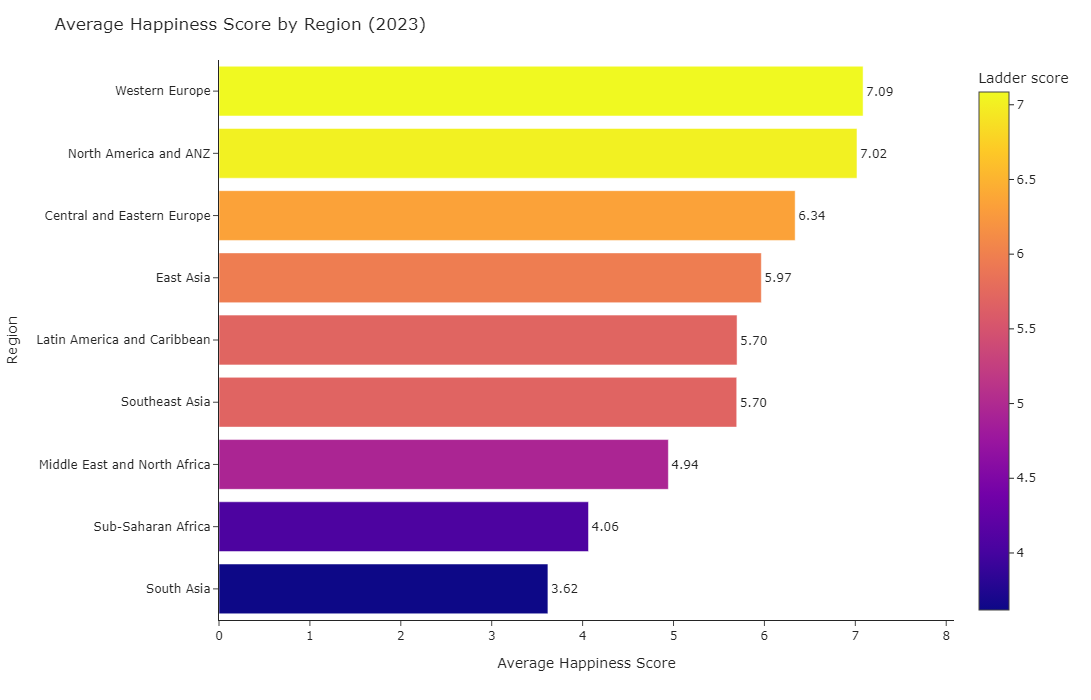

In [7]:
# =========================
# TASK 1 — FULL SOLUTION
# =========================

# Imports
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\data-viz-class-material\data\world_happiness_2023.csv"
)

# Check columns
print(df.columns)

# ---- IMPORTANT ----
# Adjust these column names if necessary
# Common 2023 names:
# 'Country name'
# 'Regional indicator'
# 'Ladder score'

# Average happiness score by region
region_avg = (
    df.groupby('Regional indicator')['Ladder score']
      .mean()
      .reset_index()
      .sort_values('Ladder score', ascending=True)
)

# Create horizontal bar chart
fig = px.bar(
    region_avg,
    x='Ladder score',
    y='Regional indicator',
    orientation='h',
    text='Ladder score',
    color='Ladder score'
)

# Format labels
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

# Layout improvements
fig.update_layout(
    title='Average Happiness Score by Region (2023)',
    xaxis_title='Average Happiness Score',
    yaxis_title='Region',
    template='simple_white',
    height=700
)

# Zero baseline
fig.update_xaxes(range=[0, region_avg['Ladder score'].max() + 1])

# Show chart
fig.show()

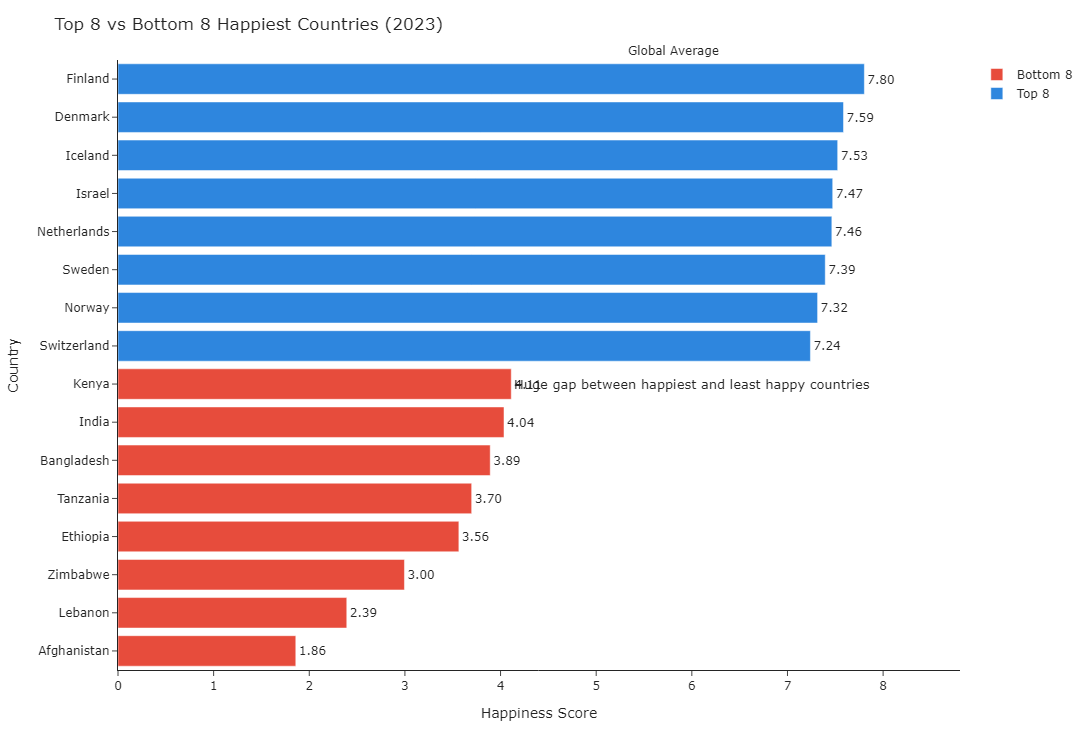

In [8]:
# =========================
# TASK 2 
# =========================

# Imports
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\data-viz-class-material\data\world_happiness_2023.csv"
)

# -------------------------
# Top 8 happiest countries
# -------------------------
top8 = (
    df.nlargest(8, 'Ladder score')
    [['Country name', 'Ladder score']]
    .copy()
)

top8['Group'] = 'Top 8'

# -------------------------
# Bottom 8 happiest countries
# -------------------------
bottom8 = (
    df.nsmallest(8, 'Ladder score')
    [['Country name', 'Ladder score']]
    .copy()
)

bottom8['Group'] = 'Bottom 8'

# Combine both datasets
combined = pd.concat([top8, bottom8])

# Sort for better display
combined = combined.sort_values('Ladder score')

# Global average happiness score
global_avg = df['Ladder score'].mean()

# Custom colours
colors = {
    'Top 8': '#2E86DE',
    'Bottom 8': '#E74C3C'
}

# Create chart
fig = px.bar(
    combined,
    x='Ladder score',
    y='Country name',
    orientation='h',
    color='Group',
    text='Ladder score',
    color_discrete_map=colors
)

# Improve labels
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

# Add global average reference line
fig.add_vline(
    x=global_avg,
    line_dash='dash',
    line_color='black',
    annotation_text='Global Average',
    annotation_position='top'
)

# Add annotation
fig.add_annotation(
    x=6,
    y=7,
    text='Huge gap between happiest and least happy countries',
    showarrow=False,
    font=dict(size=13)
)

# Layout
fig.update_layout(
    title='Top 8 vs Bottom 8 Happiest Countries (2023)',
    xaxis_title='Happiness Score',
    yaxis_title='Country',
    template='simple_white',
    height=750,
    legend_title=''
)

# Zero baseline
fig.update_xaxes(range=[0, combined['Ladder score'].max() + 1])

# Show chart
fig.show()